In [1]:
!pip install torchsummary

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchsummary import summary
import matplotlib.pyplot as plt
import numpy as np

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
# Transform: Convert to tensor and normalize, plus a simple augmentation
transform_train = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load MNIST dataset
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

print(f"Training samples: {len(trainset)} | Testing samples: {len(testset)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 499kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.59MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.14MB/s]


Training samples: 60000 | Testing samples: 10000


In [3]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Input: 1x28x28 (MNIST grayscale)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # Output: 16x14x14

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # Output: 32x7x7

        self.fc = nn.Linear(32 * 7 * 7, 10) # 10 classes for MNIST

    def forward(self, x):
        # We save intermediate steps as attributes to easily visualize them later
        self.out_conv1 = self.conv1(x)
        self.out_relu1 = self.relu1(self.out_conv1)
        self.out_pool1 = self.pool1(self.out_relu1)

        self.out_conv2 = self.conv2(self.out_pool1)
        self.out_relu2 = self.relu2(self.out_conv2)
        self.out_pool2 = self.pool2(self.out_relu2)

        out = self.out_pool2.view(-1, 32 * 7 * 7) # Flatten
        out = self.fc(out)
        return out

model = SimpleCNN().to(device)
summary(model, (1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 28, 28]             160
              ReLU-2           [-1, 16, 28, 28]               0
         MaxPool2d-3           [-1, 16, 14, 14]               0
            Conv2d-4           [-1, 32, 14, 14]           4,640
              ReLU-5           [-1, 32, 14, 14]               0
         MaxPool2d-6             [-1, 32, 7, 7]               0
            Linear-7                   [-1, 10]          15,690
Total params: 20,490
Trainable params: 20,490
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.32
Params size (MB): 0.08
Estimated Total Size (MB): 0.40
----------------------------------------------------------------


Epoch 1/3 | Loss: 0.2279 | Accuracy: 93.33%
Epoch 2/3 | Loss: 0.0741 | Accuracy: 97.72%
Epoch 3/3 | Loss: 0.0579 | Accuracy: 98.24%


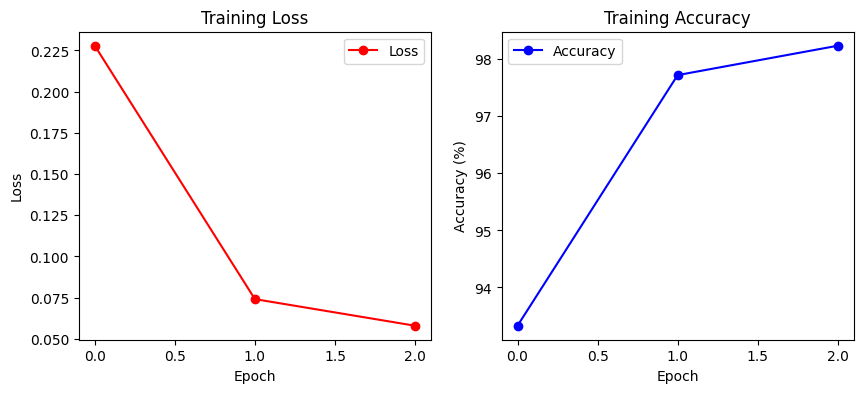

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 3

train_losses, train_accuracies = [], []

for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(trainloader)
    epoch_acc = 100. * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Loss', color='red', marker='o')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Accuracy', color='blue', marker='o')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()

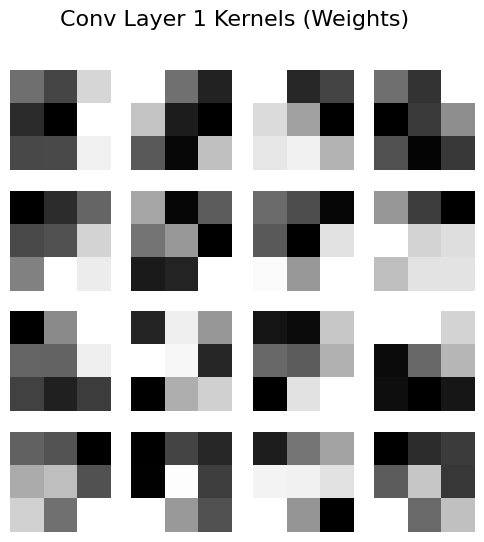


--- Feature Maps ---


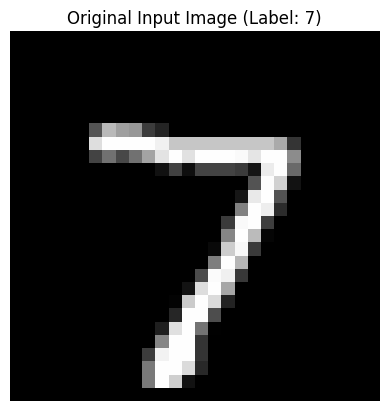

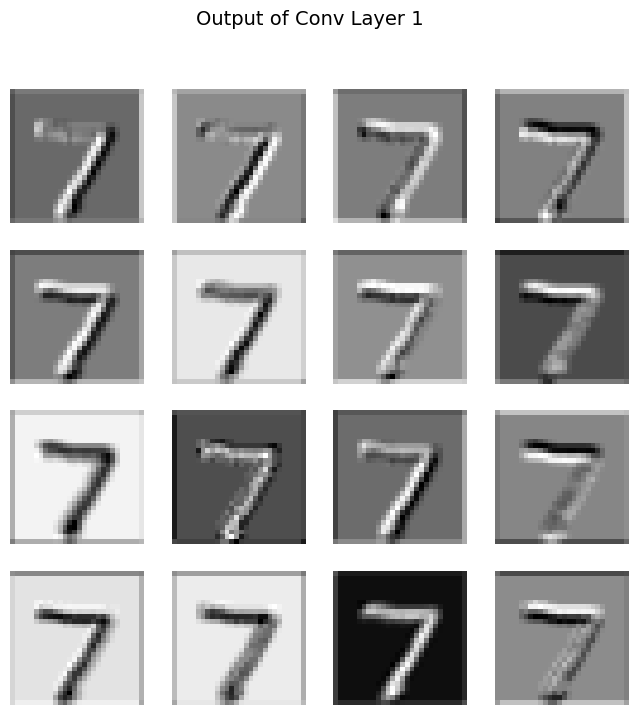

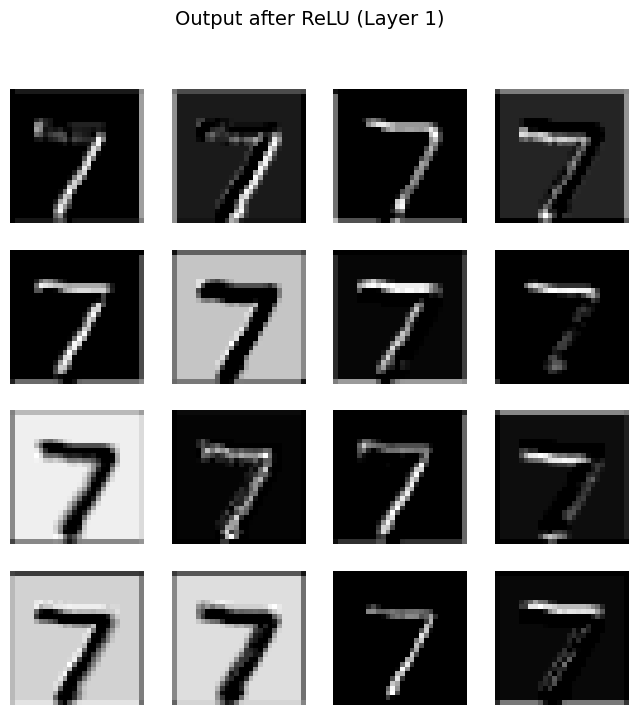

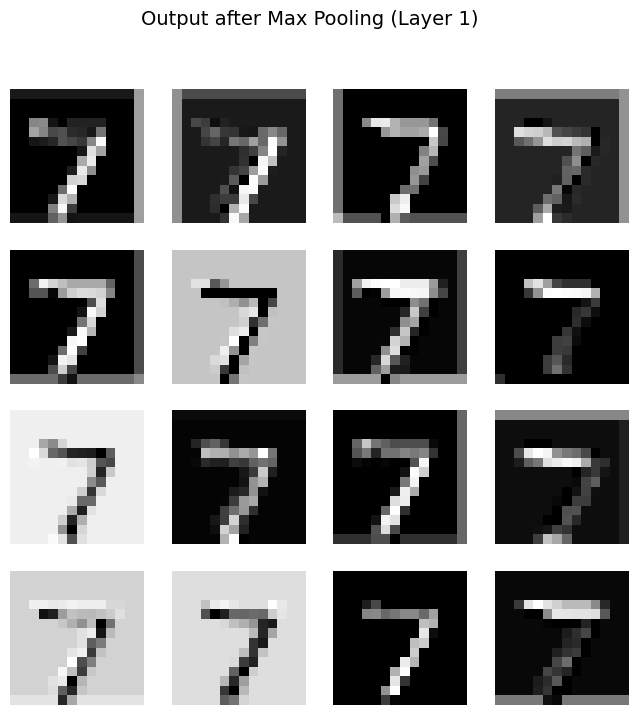

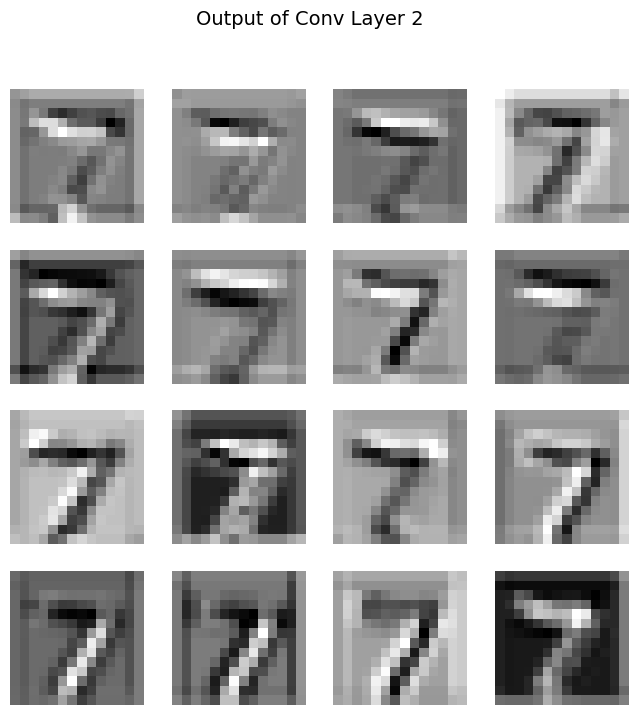

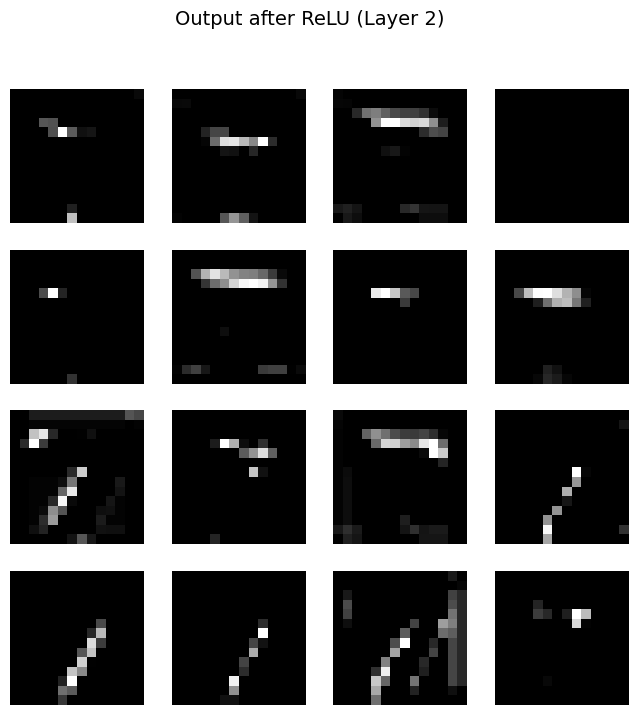

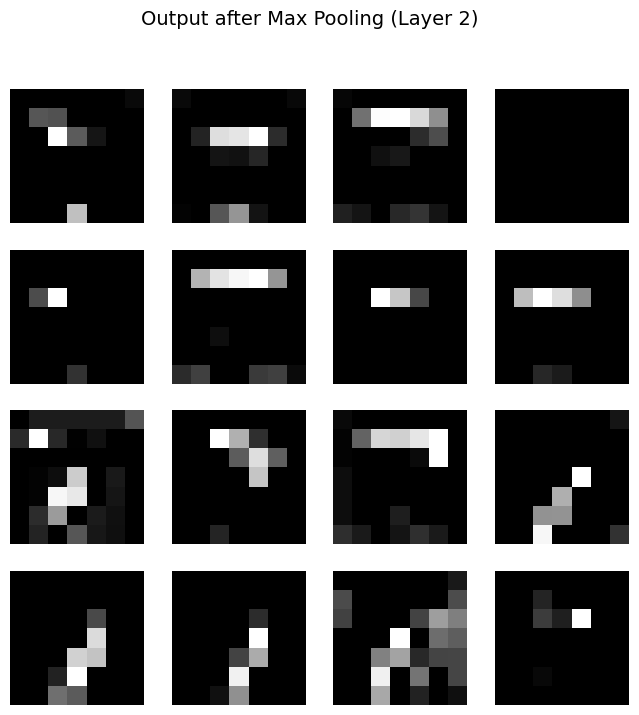

In [6]:
model.eval()

# 1. Visualize Kernels of Conv Layer 1
kernels = model.conv1.weight.detach().cpu().numpy()
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
fig.suptitle('Conv Layer 1 Kernels (Weights)', fontsize=16)
for i, ax in enumerate(axes.flatten()):
    ax.imshow(kernels[i][0], cmap='gray')
    ax.axis('off')
plt.show()

# 2. Visualize Feature Maps
dataiter = iter(testloader)
images, labels = next(dataiter)
sample_img = images[0].unsqueeze(0).to(device) # Take first image and add batch dimension

# Forward pass to generate internal states
_ = model(sample_img)

def plot_feature_maps(feature_map_tensor, title):
    fmaps = feature_map_tensor.detach().cpu().numpy()[0]
    num_maps = min(16, fmaps.shape[0])
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    fig.suptitle(title, fontsize=14)
    for i, ax in enumerate(axes.flatten()):
        if i < num_maps:
            ax.imshow(fmaps[i], cmap='grey')
        ax.axis('off')
    plt.show()

print("\n--- Feature Maps ---")
plt.imshow(sample_img.cpu().squeeze(), cmap='gray')
plt.title(f"Original Input Image (Label: {labels[0]})")
plt.axis('off')
plt.show()

plot_feature_maps(model.out_conv1, "Output of Conv Layer 1")
plot_feature_maps(model.out_relu1, "Output after ReLU (Layer 1)")
plot_feature_maps(model.out_pool1, "Output after Max Pooling (Layer 1)")
plot_feature_maps(model.out_conv2, "Output of Conv Layer 2")
plot_feature_maps(model.out_relu2, "Output after ReLU (Layer 2)")
plot_feature_maps(model.out_pool2, "Output after Max Pooling (Layer 2)")

Test Accuracy: 98.56%



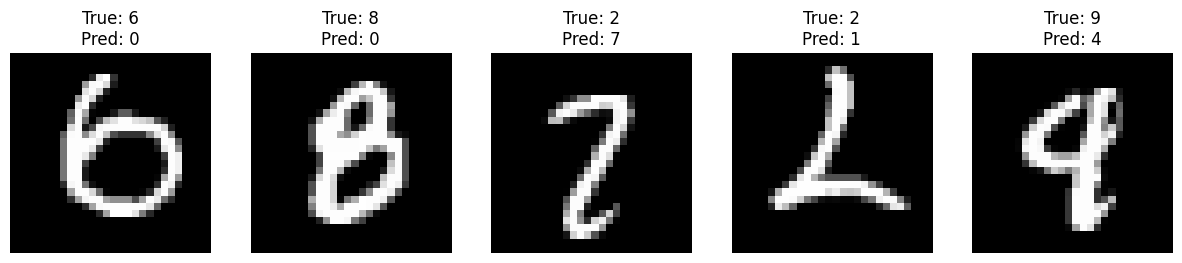

In [7]:
model.eval()
correct, total = 0, 0
misclassified_images = []
misclassified_labels = []
misclassified_preds = []

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        # Track misclassifications
        incorrect_mask = predicted != labels
        if incorrect_mask.any():
            for i in range(len(incorrect_mask)):
                if incorrect_mask[i] and len(misclassified_images) < 5:
                    misclassified_images.append(inputs[i].cpu())
                    misclassified_labels.append(labels[i].item())
                    misclassified_preds.append(predicted[i].item())

print(f"Test Accuracy: {100. * correct / total:.2f}%\n")

# Plot misclassifications
fig, axes = plt.subplots(1, len(misclassified_images), figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(misclassified_images[i].squeeze(), cmap='gray')
    ax.set_title(f"True: {misclassified_labels[i]}\nPred: {misclassified_preds[i]}")
    ax.axis('off')
plt.show()

# Part 3: Questions for Understanding

### 1. Architecture & Design
* **Why do we typically use small kernels (like 3x3) instead of large ones (like 7x7 or 11x11) in modern architectures?**
    Small kernels are more computationally efficient and significantly reduce the number of trainable parameters, which helps prevent overfitting. By stacking multiple 3x3 layers, we can achieve the same effective receptive field as a single larger kernel (e.g., two 3x3 layers equal one 5x5) while introducing more non-linearity through additional activation functions.
* **What is the difference between "Valid" and "Same" padding?**
    * **Valid Padding:** No padding is applied. The spatial dimensions of the output decrease after each convolution ($N - F + 1$).
    * **Same Padding:** Zero-padding is added to the edges of the input so that the output has the same spatial dimensions as the input (when stride is 1).

### 2. Activation Functions
* **Why is ReLU preferred over Sigmoid in the hidden layers of a deep CNN?**
    ReLU (Rectified Linear Unit) helps mitigate the "Vanishing Gradient" problem, as its derivative is 1 for all positive inputs, allowing deeper networks to train faster. Additionally, ReLU is computationally cheaper since it only involves a thresholding operation ($max(0, x)$).
* **What happens to the gradients when a ReLU unit outputs 0?**
    The gradient becomes zero. This can lead to the "Dying ReLU" problem, where certain neurons become inactive and stop updating their weights during backpropagation because they no longer contribute to the learning process.

### 3. Pooling
* **What is the primary purpose of Max Pooling? Does it have any trainable parameters?**
    The primary purpose of Max Pooling is to downsample the feature maps, reducing the spatial dimensions and computational complexity. It helps extract the most prominent features in a local neighborhood. Max Pooling has **no** trainable parameters (no weights or biases).
* **How does pooling contribute to "translational invariance"?**
    By taking the maximum value in a window (e.g., 2x2), the exact location of a feature becomes less critical. If an edge or shape shifts by a few pixels, the maximum value in that pooling region often remains the same, making the model robust to small shifts or distortions in the input image.

### 4. Training & Regularization
* **If your model has high training accuracy but low test accuracy, what is happening, and how would you fix it?**
    This indicates **overfitting**, where the model has memorized the training data instead of learning general patterns. To fix this, you can:
    1. Add regularization (Dropout or L2 Weight Decay).
    2. Use Data Augmentation (rotations, scaling).
    3. Simplify the model architecture.
    4. Collect more training data.
* **How does Dropout help prevent overfitting in a CNN?**
    Dropout randomly "drops" a percentage of neurons during each training iteration. This prevents neurons from co-adapting too much and forces the network to learn more robust, redundant representations of the data.